In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device}')

Using cuda


In [3]:
data = pd.read_csv('data.csv').to_numpy()
data = (data - data.mean(axis=1).reshape(-1, 1)) / data.std(axis=1).reshape(-1, 1)

In [11]:
# plt.rcParams['ps.fonttype'] = 42   # Тип шрифтов для EPS (Type 1)
# plt.rcParams['text.usetex'] = True # Использовать шрифты LaTeX (опционально)

In [4]:
import matplotlib

size = 15
matplotlib.rc('font', size=size)
matplotlib.rc('axes', titlesize=size)

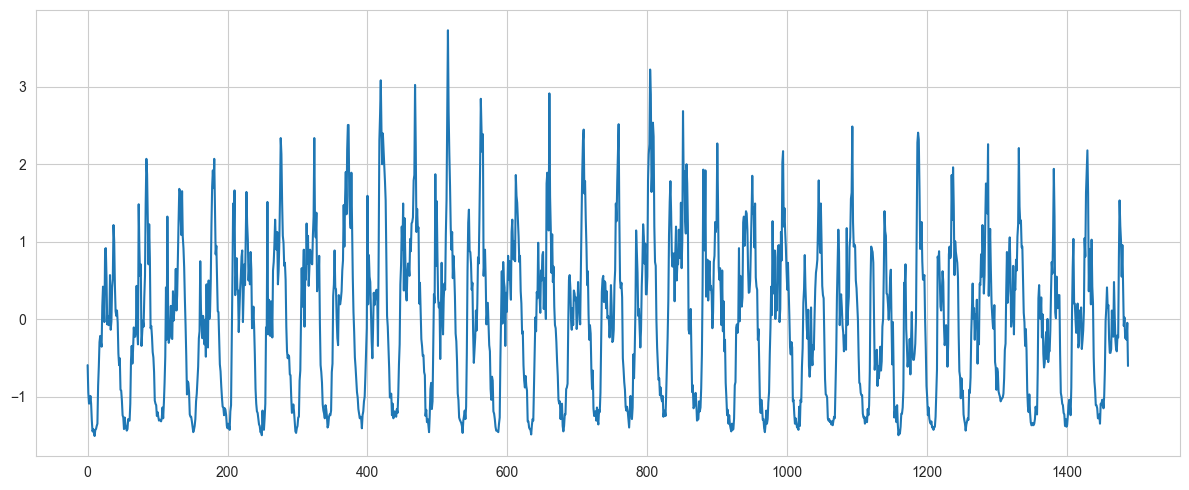

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(data[0])
plt.tight_layout()

In [6]:
train_length = round(len(data) * 0.8)
train_data = torch.tensor(data[:train_length], dtype=torch.float32)
test_data = torch.tensor(data[train_length:], dtype=torch.float32)
all_data = torch.tensor(data, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_data), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(test_data), batch_size=16, shuffle=False)
all_loader = DataLoader(TensorDataset(all_data), batch_size=16, shuffle=True)

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim, d1, d2):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, d1),
            nn.ReLU(),
            nn.Linear(d1, d2),
            nn.ReLU(),
            nn.Linear(d2, encoding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, d2),
            nn.ReLU(),
            nn.Linear(d2, d1),
            nn.ReLU(),
            nn.Linear(d1, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [8]:
# Создание модели
model = Autoencoder(input_dim=1488, encoding_dim=48, d1=156, d2=84).to(device)

# Определение функции потерь и оптимизатора
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

In [9]:
k = 0
for param in model.parameters():
    if param.requires_grad:
        k += torch.prod(torch.tensor(param.size()))
print(f'Model has {k} trainable parameters')

Model has 500544 trainable parameters


In [10]:
all_train_losses = []
train_losses = []
test_losses = []

In [15]:
epochs = 100

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in train_loader:
        
        batch = batch[0].to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        all_train_losses.append(loss.item())
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')
    train_losses.append(avg_loss)
    
    model.eval()
    avg_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch[0].to(device)
            preds = model(batch)
            loss = criterion(preds, batch)
            
            avg_test_loss += loss.item()
    avg_test_loss /= len(test_loader)
    test_losses.append(avg_test_loss)
    print(f'Test Loss: {avg_test_loss:.4f}')

Epoch 1, Loss: 0.3156
Test Loss: 0.3406
Epoch 2, Loss: 0.3131
Test Loss: 0.3401
Epoch 3, Loss: 0.3130
Test Loss: 0.3397
Epoch 4, Loss: 0.3121
Test Loss: 0.3394
Epoch 5, Loss: 0.3112
Test Loss: 0.3394
Epoch 6, Loss: 0.3101
Test Loss: 0.3401
Epoch 7, Loss: 0.3103
Test Loss: 0.3385
Epoch 8, Loss: 0.3106
Test Loss: 0.3381
Epoch 9, Loss: 0.3069
Test Loss: 0.3376
Epoch 10, Loss: 0.3084
Test Loss: 0.3376
Epoch 11, Loss: 0.3100
Test Loss: 0.3378
Epoch 12, Loss: 0.3060
Test Loss: 0.3369
Epoch 13, Loss: 0.3057
Test Loss: 0.3375
Epoch 14, Loss: 0.3057
Test Loss: 0.3374
Epoch 15, Loss: 0.3059
Test Loss: 0.3372
Epoch 16, Loss: 0.3043
Test Loss: 0.3363
Epoch 17, Loss: 0.3032
Test Loss: 0.3367
Epoch 18, Loss: 0.3036
Test Loss: 0.3362
Epoch 19, Loss: 0.3019
Test Loss: 0.3359
Epoch 20, Loss: 0.3016
Test Loss: 0.3359
Epoch 21, Loss: 0.3017
Test Loss: 0.3355
Epoch 22, Loss: 0.2998
Test Loss: 0.3359
Epoch 23, Loss: 0.3003
Test Loss: 0.3359
Epoch 24, Loss: 0.2994
Test Loss: 0.3356
Epoch 25, Loss: 0.2991
Te

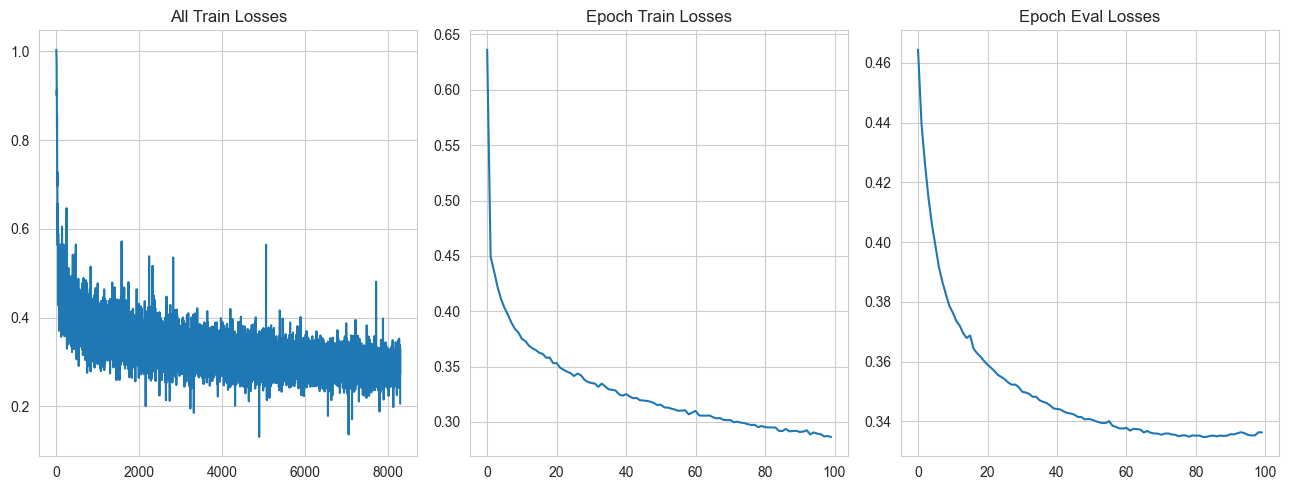

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].plot(all_train_losses)
axes[0].set_title('All Train Losses')
axes[1].plot(train_losses)
axes[1].set_title('Epoch Train Losses')
axes[2].plot(test_losses)
axes[2].set_title('Epoch Eval Losses')
plt.tight_layout()
plt.show()

In [17]:
# Создание модели
model = Autoencoder(input_dim=1488, encoding_dim=48, d1=156, d2=84).to(device)

# Определение функции потерь и оптимизатора
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

In [18]:
k = 0
for param in model.parameters():
    if param.requires_grad:
        k += torch.prod(torch.tensor(param.size()))
print(f'Model has {k} trainable parameters')

Model has 500544 trainable parameters


In [19]:
epochs = 70

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in all_loader:
        
        batch = batch[0].to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch 1, Loss: 0.7407
Epoch 2, Loss: 0.5476
Epoch 3, Loss: 0.5218
Epoch 4, Loss: 0.5074
Epoch 5, Loss: 0.4975
Epoch 6, Loss: 0.4892
Epoch 7, Loss: 0.4799
Epoch 8, Loss: 0.4729
Epoch 9, Loss: 0.4669
Epoch 10, Loss: 0.4625
Epoch 11, Loss: 0.4577
Epoch 12, Loss: 0.4541
Epoch 13, Loss: 0.4505
Epoch 14, Loss: 0.4469
Epoch 15, Loss: 0.4437
Epoch 16, Loss: 0.4407
Epoch 17, Loss: 0.4385
Epoch 18, Loss: 0.4361
Epoch 19, Loss: 0.4331
Epoch 20, Loss: 0.4312
Epoch 21, Loss: 0.4285
Epoch 22, Loss: 0.4263
Epoch 23, Loss: 0.4240
Epoch 24, Loss: 0.4222
Epoch 25, Loss: 0.4203
Epoch 26, Loss: 0.4181
Epoch 27, Loss: 0.4163
Epoch 28, Loss: 0.4148
Epoch 29, Loss: 0.4130
Epoch 30, Loss: 0.4115
Epoch 31, Loss: 0.4100
Epoch 32, Loss: 0.4084
Epoch 33, Loss: 0.4068
Epoch 34, Loss: 0.4056
Epoch 35, Loss: 0.4047
Epoch 36, Loss: 0.4031
Epoch 37, Loss: 0.4013
Epoch 38, Loss: 0.4002
Epoch 39, Loss: 0.3987
Epoch 40, Loss: 0.3977
Epoch 41, Loss: 0.3964
Epoch 42, Loss: 0.3955
Epoch 43, Loss: 0.3941
Epoch 44, Loss: 0.39

In [84]:
# torch.save(model.state_dict(), 'models/AE.pt')

In [24]:
errors = []
encoded = []
reconstructed = []
with torch.no_grad():
    for sample in all_data:
        inputs = sample.view(1, 1, -1).to(device)
        res = model(inputs).cpu().detach().flatten()
        reconstruction_error = criterion(res, sample)
        errors.append(reconstruction_error.numpy())

        features = model.encoder(inputs).view(-1)
        encoded.append(features.cpu().detach().numpy())

        reconstructed.append(res.view(-1).cpu().detach().numpy())

errors = np.array(errors)
encoded = np.array(encoded)
reconstructed = np.array(reconstructed)

In [44]:
def plot_sample(sample):
    _, ax = plt.subplots(figsize=(20, 5))
    ax.plot(data[sample], label='True')
    pred_row = reconstructed[sample]
    ax.plot(pred_row, label='Predicted')
    mse = np.linalg.norm(data[sample] - pred_row) ** 2 / len(data[sample])
    ax.set_title(f'Model Prediction VS True Series, MSE: {mse.round(2)}, Sample: {sample}')
    plt.legend()
    plt.show()

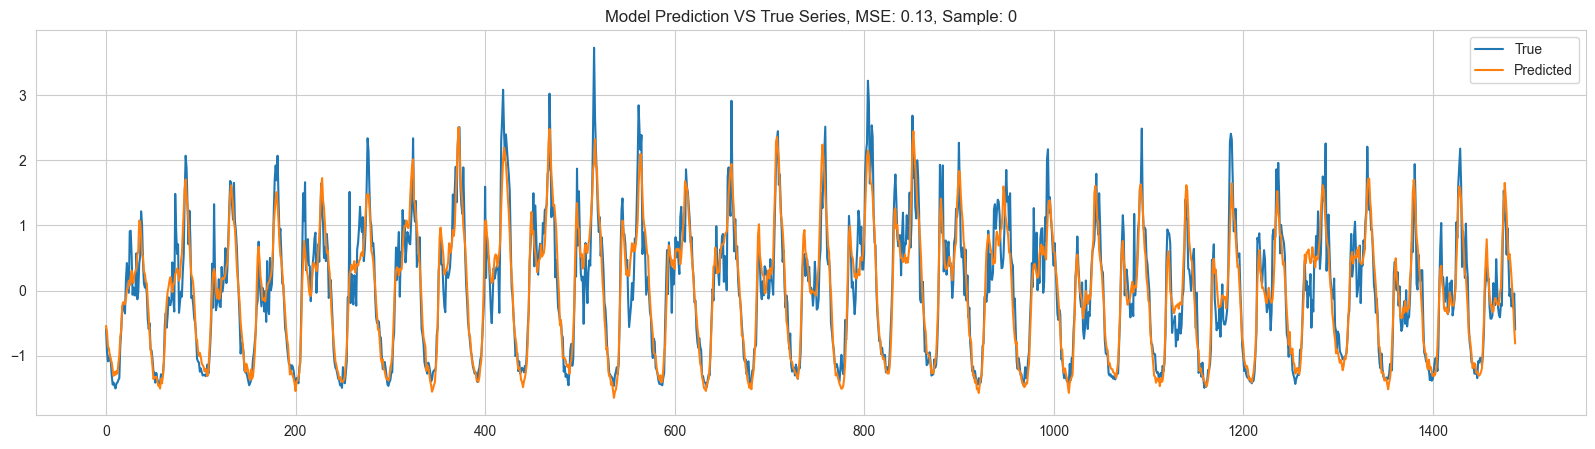

In [45]:
plot_sample(0)

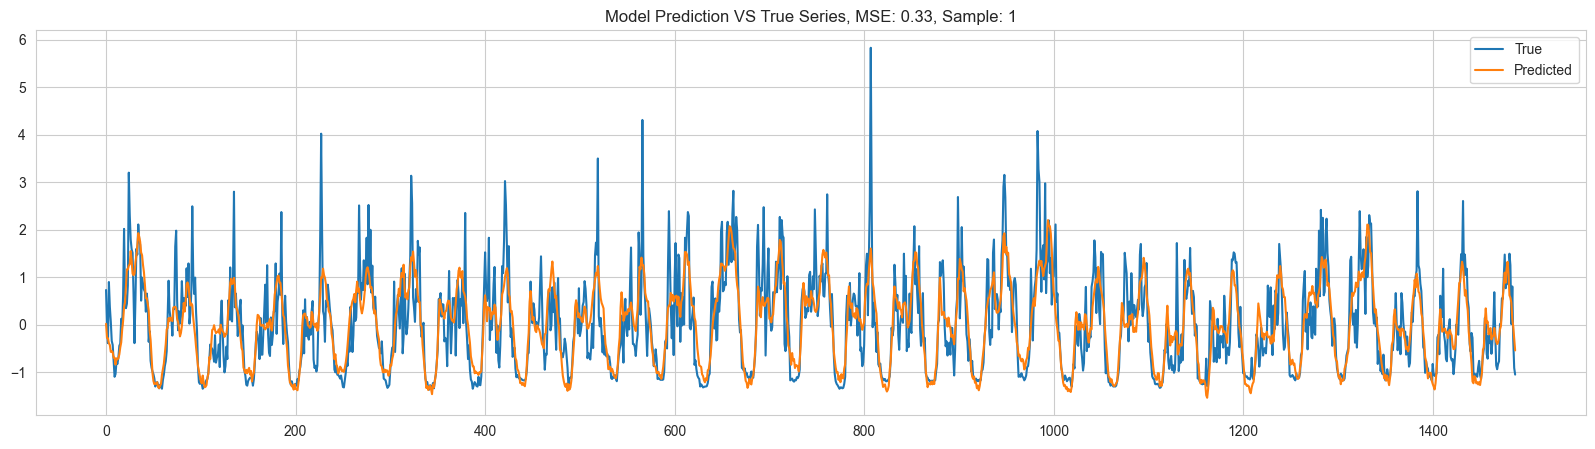

In [46]:
plot_sample(1)

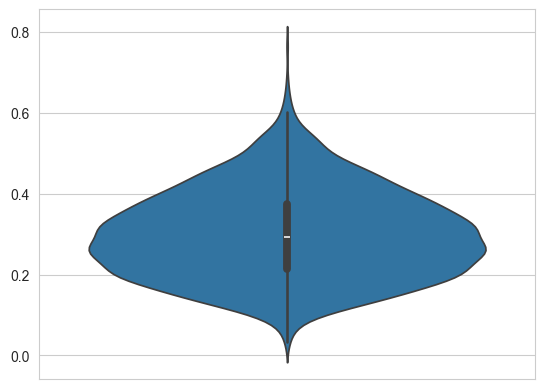

In [28]:
sns.violinplot(errors)
plt.show()

In [29]:
np.quantile(errors, 0.99)

0.56596478164196

In [30]:
np.column_stack((np.argsort(-errors), -np.sort(-errors)))

array([[1.57800000e+03, 7.64166474e-01],
       [1.42000000e+02, 6.80829883e-01],
       [5.36000000e+02, 6.44298613e-01],
       ...,
       [1.10200000e+03, 4.97362427e-02],
       [6.54000000e+02, 3.76015157e-02],
       [2.23000000e+02, 3.31652798e-02]])

In [ ]:
# 1578.0,0.764166
# 142.0,0.680830
# 536.0,0.644299
# 908.0,0.639557
# 394.0,0.628049
# 1283.0,0.614471
# 523.0,0.600668
# 1225.0,0.600433
# 123.0,0.597769
# 383.0,0.593914

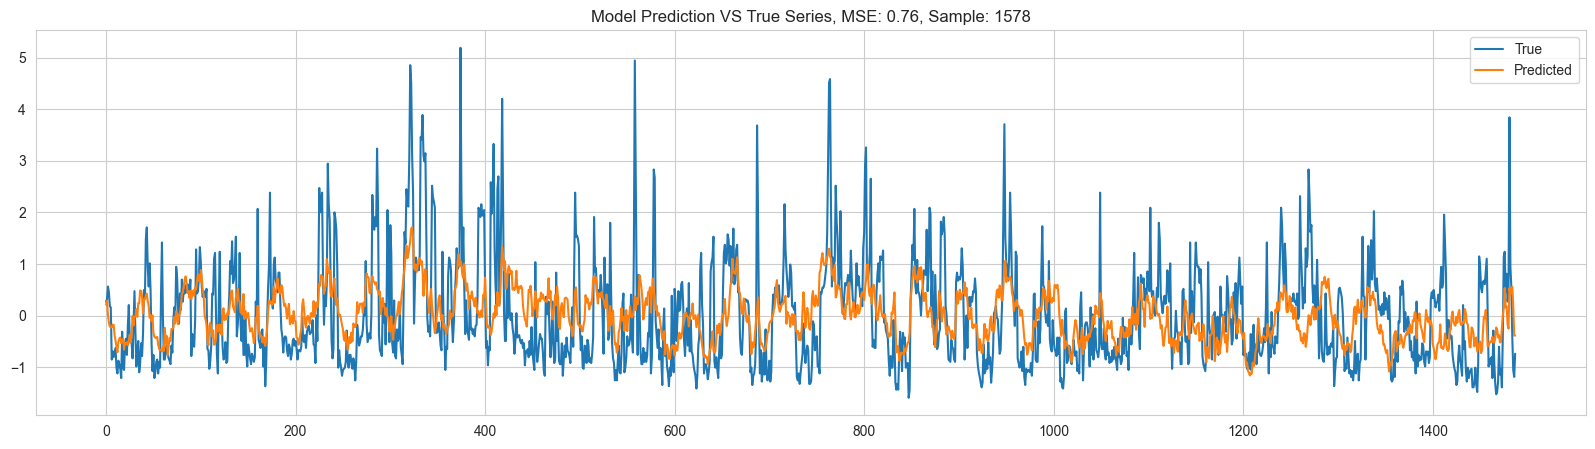

In [47]:
plot_sample(1578)

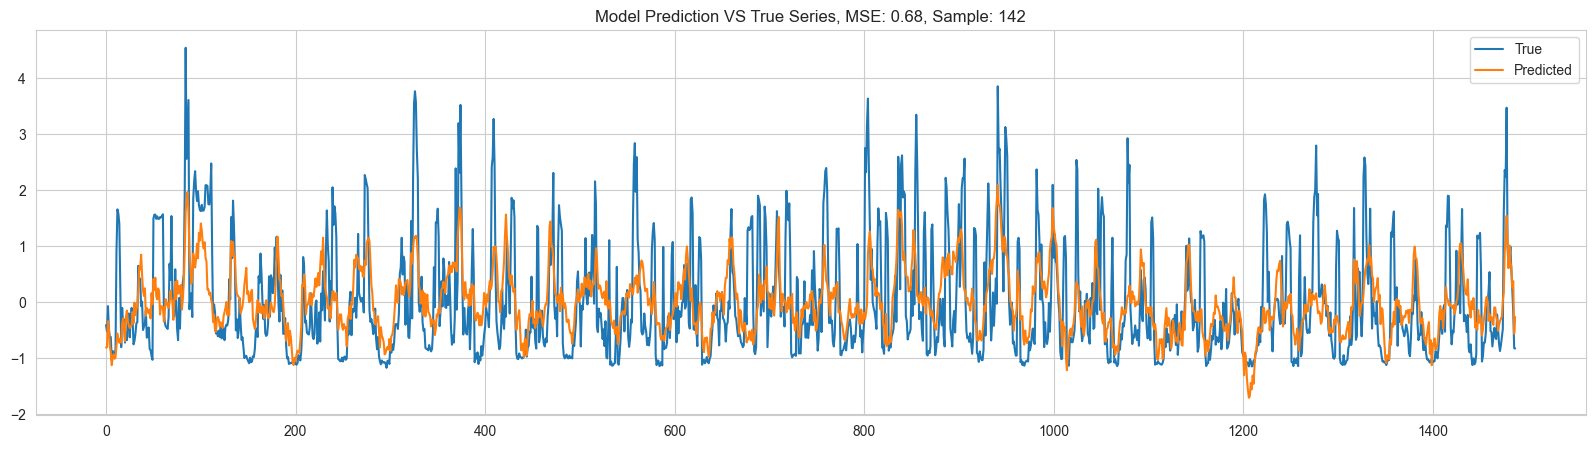

In [48]:
plot_sample(142)

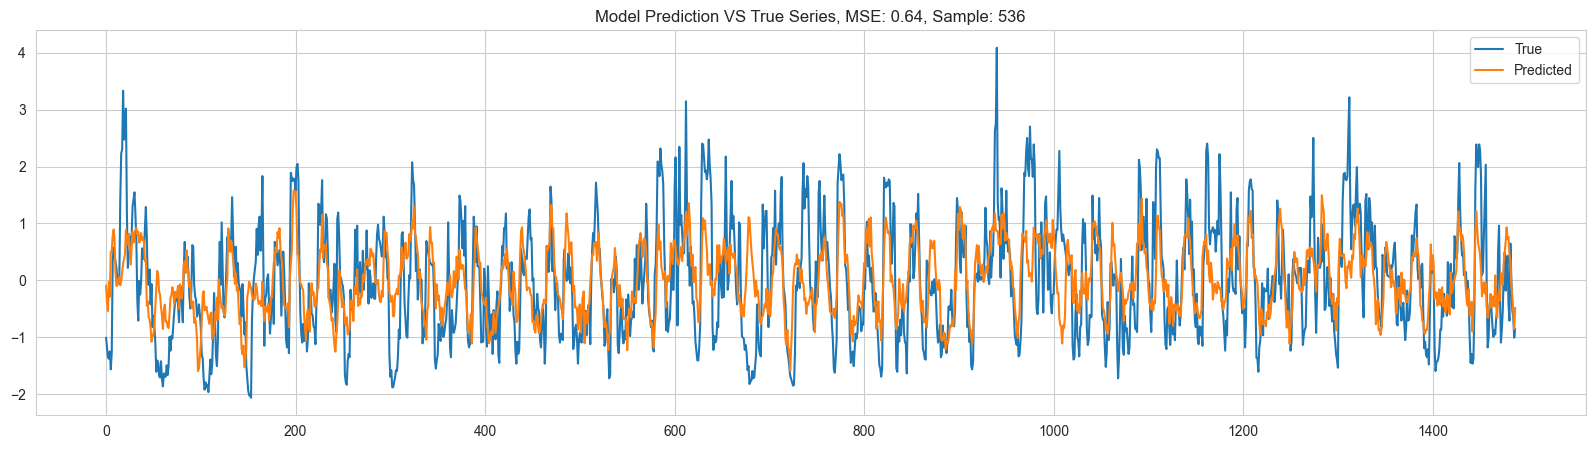

In [49]:
plot_sample(536)

In [34]:
encoded_norm = (encoded - encoded.mean(axis=0)) / encoded.std(axis=0)

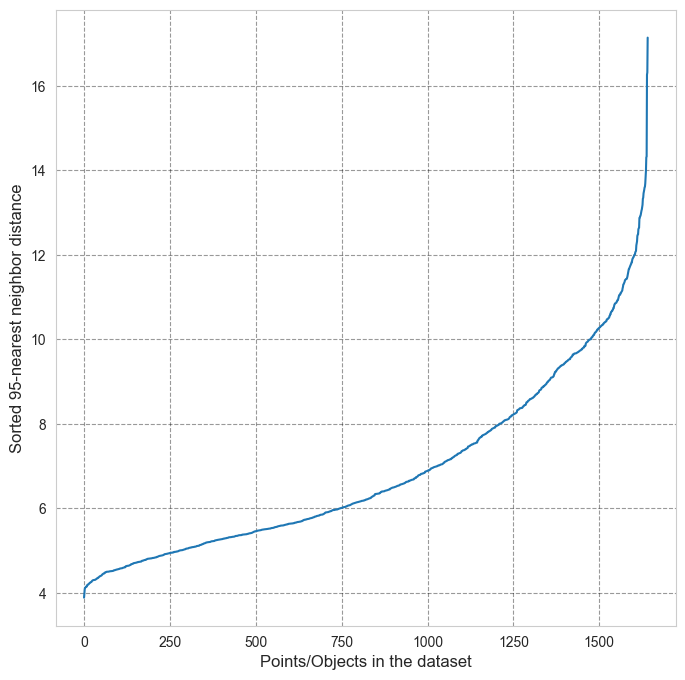

In [35]:
from sklearn.neighbors import NearestNeighbors


def get_kdist_plot(X=None, k=None, radius_nbrs=1.0):

    nbrs = NearestNeighbors(n_neighbors=k, radius=radius_nbrs).fit(X)

    # For each point, compute distances to its k-nearest neighbors
    distances, indices = nbrs.kneighbors(X)

    distances = np.sort(distances, axis=0)
    distances = distances[:, k-1]

    # Plot the sorted K-nearest neighbor distance for each point in the dataset
    plt.figure(figsize=(8,8))
    plt.plot(distances)
    plt.xlabel('Points/Objects in the dataset', fontsize=12)
    plt.ylabel('Sorted {}-nearest neighbor distance'.format(k), fontsize=12)
    plt.grid(True, linestyle="--", color='black', alpha=0.4)
    plt.show()
    plt.close()


k = 2 * encoded_norm.shape[-1] - 1 # k=2*{dim(dataset)} - 1
get_kdist_plot(X=encoded_norm, k=k)

In [40]:
from sklearn.cluster import DBSCAN

# Создаем объект DBSCAN
dbscan = DBSCAN(eps=10.823, min_samples=10)

# Проводим кластеризацию данных
clusters = dbscan.fit_predict(encoded_norm)

# Ищем объекты, отнесенные к кластеру -1 (это аномалии)
anomalies_indices = np.where(clusters == -1)[0]
anomalies_indices

array([ 412,  603, 1443], dtype=int64)

In [ ]:
# 122,  393,  412,  528,  603,  704, 1018, 1034, 1416, 1443
# 412,  603, 1443

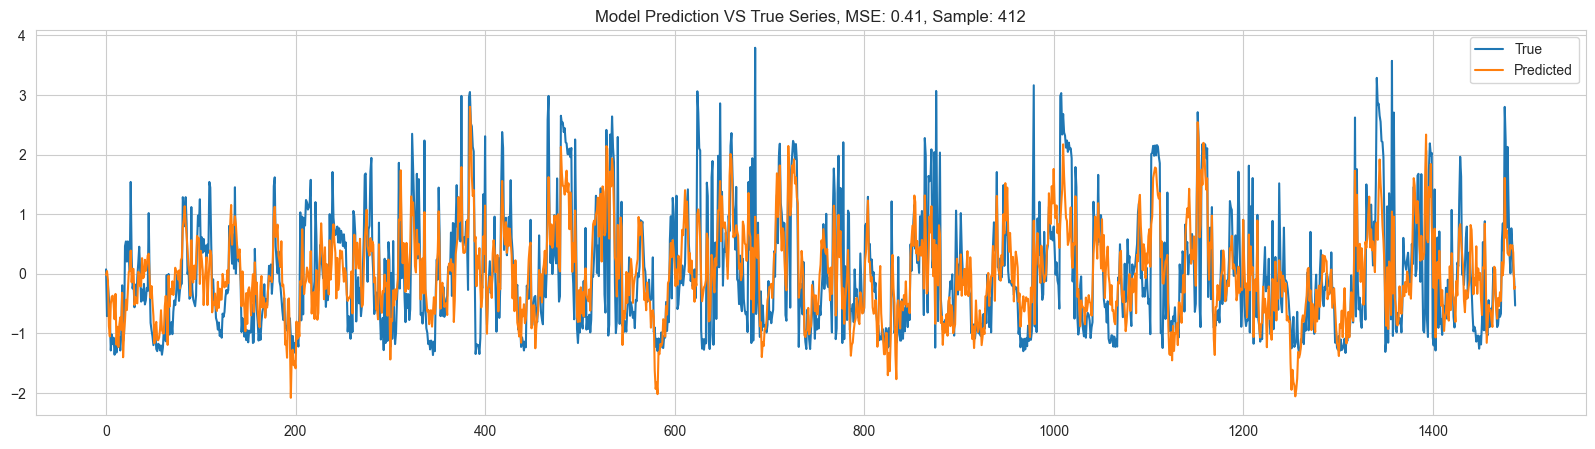

In [50]:
plot_sample(412)

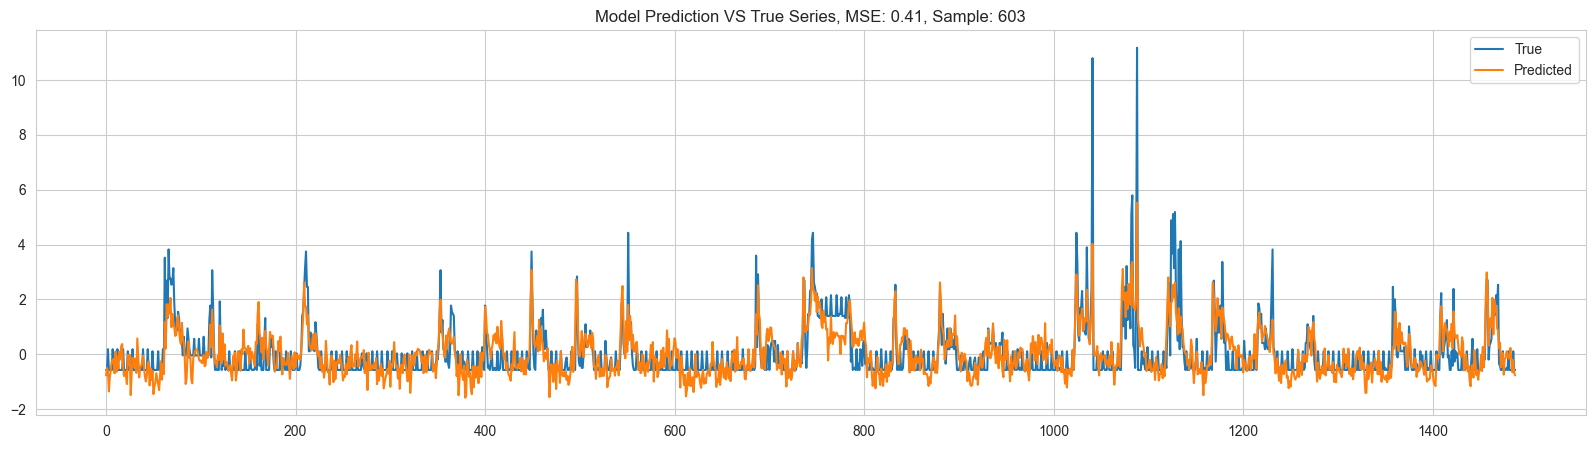

In [51]:
plot_sample(603)

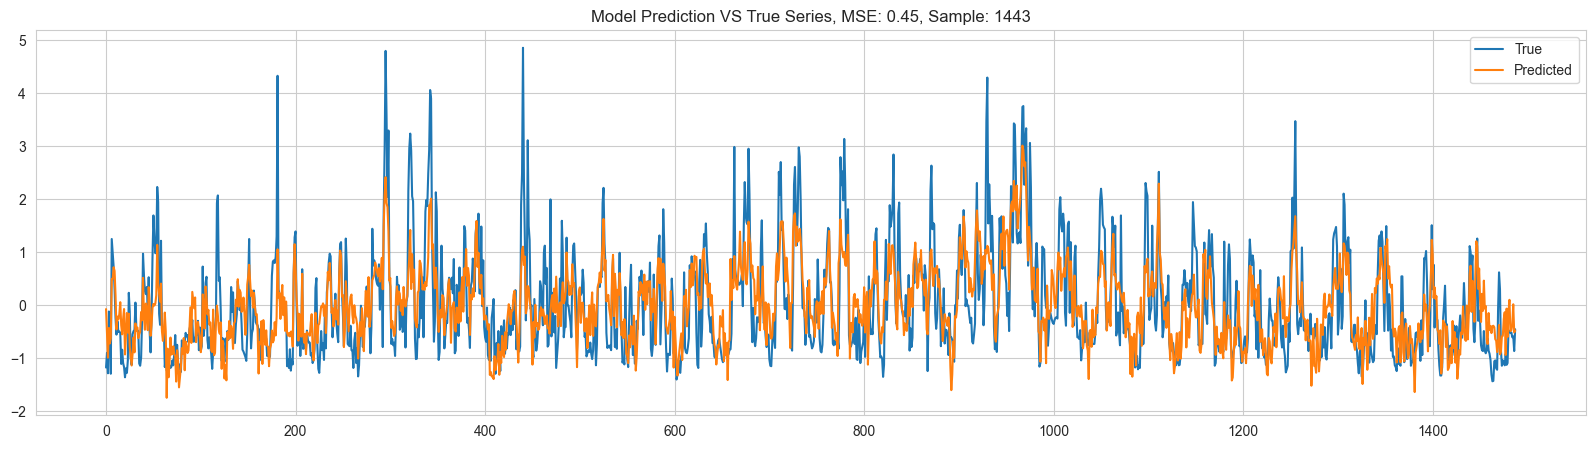

In [52]:
plot_sample(1443)

In [85]:
medians = np.median(encoded_norm, axis=0)
middle = np.repeat(np.inf, 4)
cur_min = np.inf
for sample in encoded_norm:
    dist = np.dot(sample - medians, sample - medians)
    if dist < cur_min:
        cur_min = dist
        middle = sample
q = 0.001
dists = np.linalg.norm(encoded_norm - middle, axis=1)
band = max(np.quantile(dists, q), 1e-3)
band

2.544428315639496

In [89]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel='gaussian', bandwidth=band)
kde.fit(encoded_norm)
kde_scores = kde.score_samples(encoded_norm)
min_max = 1 - (kde_scores - kde_scores.min()) / (kde_scores.max() - kde_scores.min())

<Axes: >

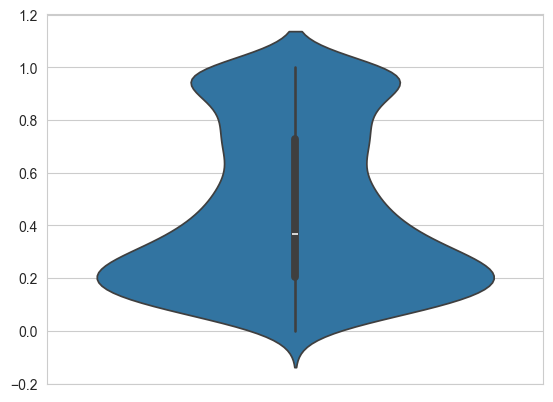

In [90]:
sns.violinplot(min_max)

In [91]:
np.vstack((-np.sort(-min_max), np.argsort(-min_max))).T

array([[1.00000000e+00, 6.03000000e+02],
       [9.99999822e-01, 4.12000000e+02],
       [9.99999394e-01, 1.44300000e+03],
       ...,
       [2.38540800e-02, 8.29000000e+02],
       [9.29147130e-03, 8.65000000e+02],
       [0.00000000e+00, 1.50500000e+03]])

In [ ]:
# 1.000000,603.0
# 1.000000,412.0
# 0.999999,1443.0
# 0.999964,1018.0
# 0.999964,122.0
# 0.999929,393.0
# 0.999906,1416.0
# 0.999893,1167.0
# 0.999861,1435.0
# 0.999809,1168.0

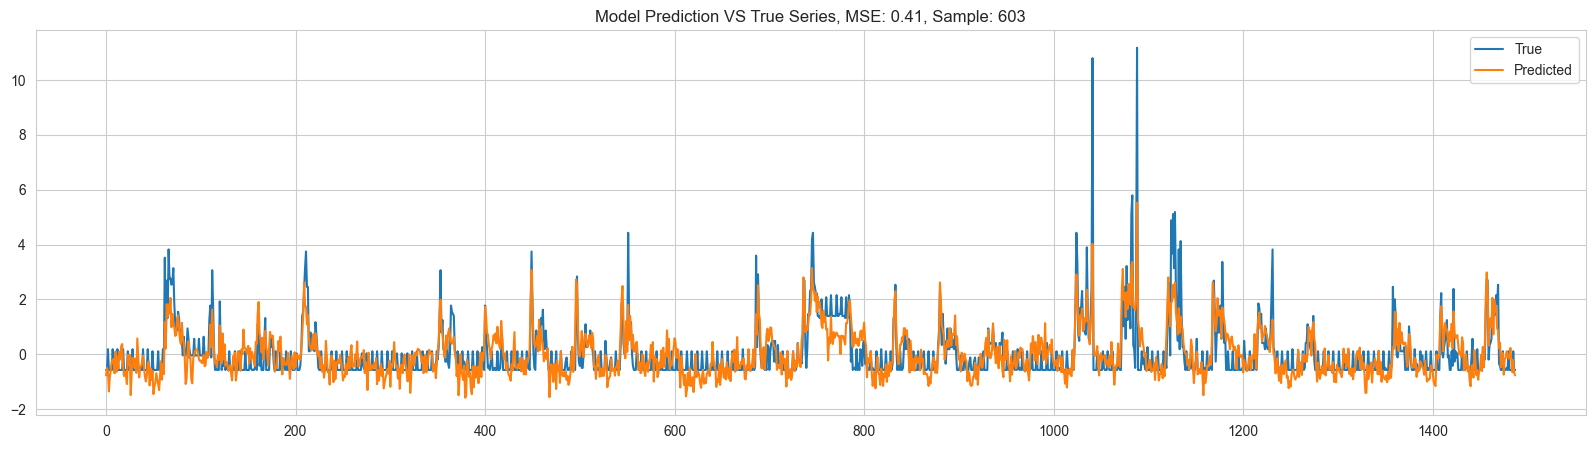

In [74]:
plot_sample(603)

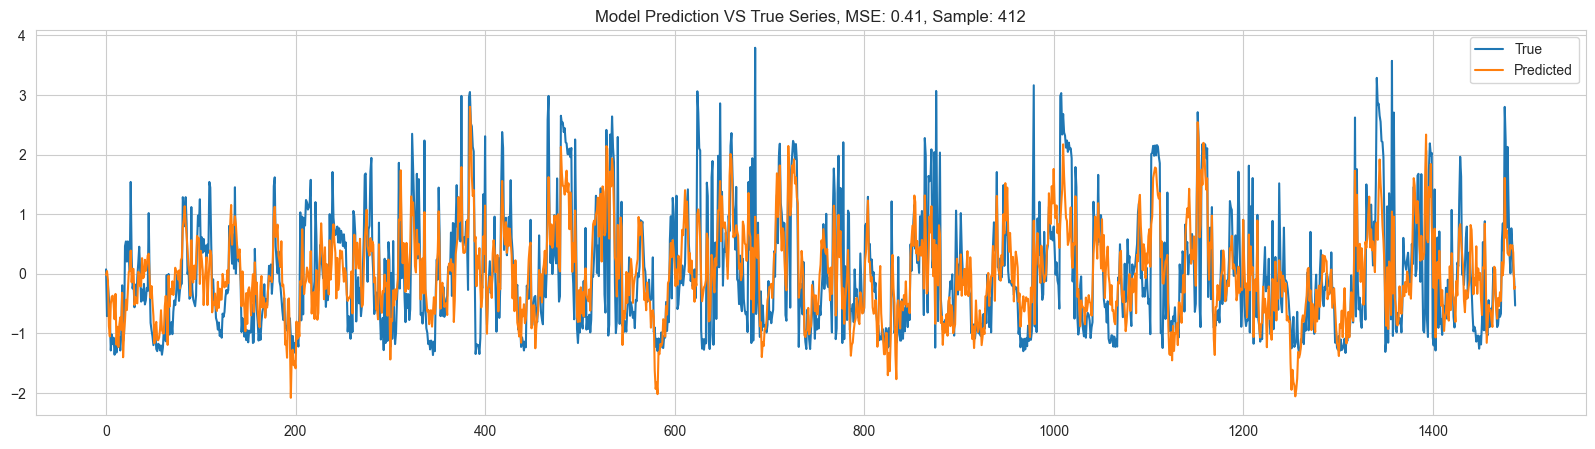

In [75]:
plot_sample(412)

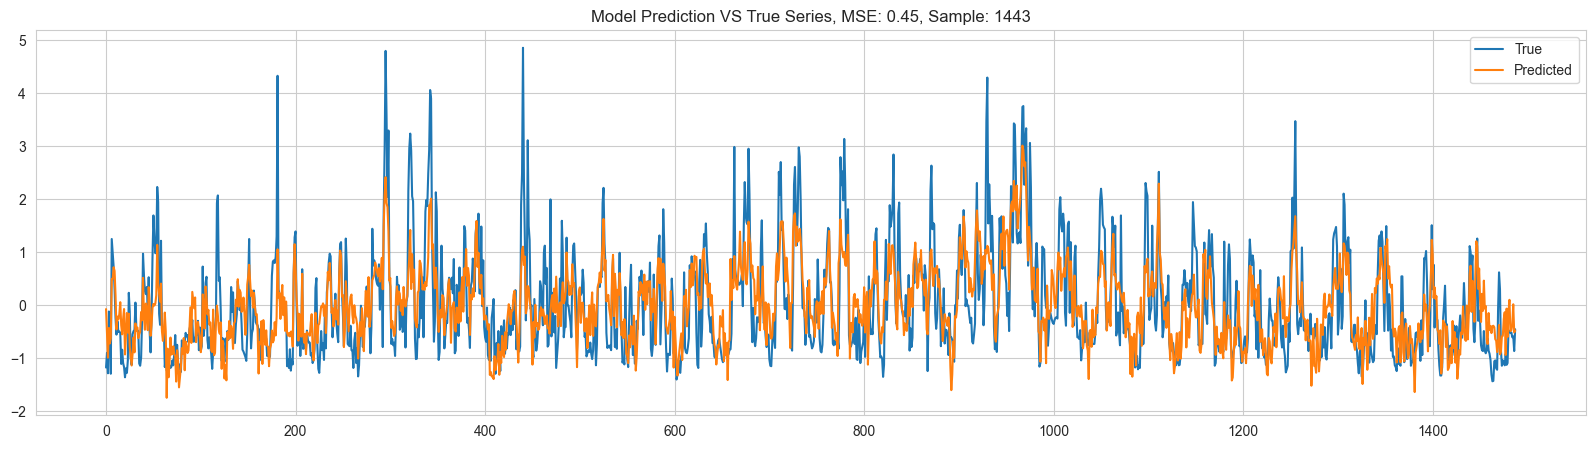

In [76]:
plot_sample(1443)